# Check cuda

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100 80GB PCIe


In [2]:
import torch_geometric
print(torch_geometric.__version__)

2.7.0


# Load log and extract traces

In [3]:
import utilities as utils

path = "logs/BPI_Challenge_2012.xes"
traces, activities = utils.extract_traces(path)

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

## Trace visualization 

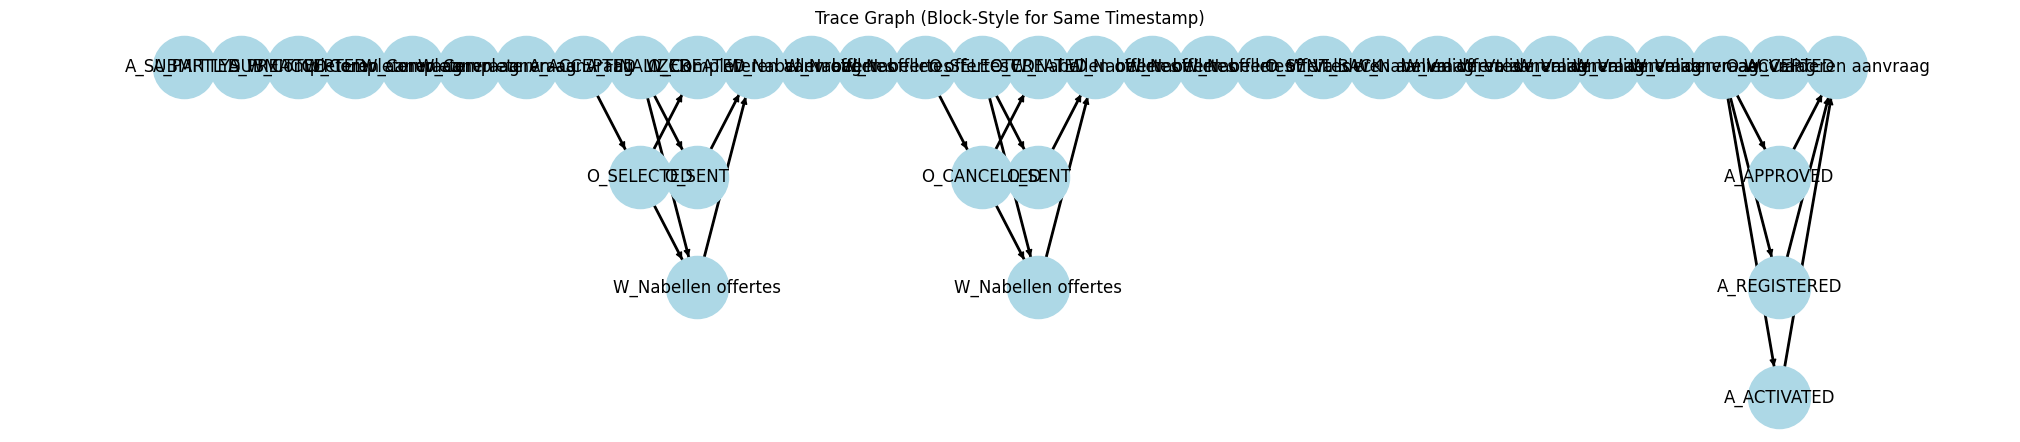

In [31]:
example = utils.truncate_trace_timestamps(traces[1], "second")
G = utils.trace_to_graph(example)
utils.visualize_block(G)

# Create graph dataloaders

In [1]:
import utilities as utils

# Load split and prepare data in train and test

# Load traces
path = "logs/BPI_Challenge_2012.xes"
traces, activities = utils.extract_traces(path)

# Create pytorch geometric batch and truncate timestamps
train_loader, val_loader, test_loader, activity_to_idx, trace_graph_ranges = utils.traces_to_pyg_loaders(traces, activities,"none")

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

Processing traces: 100%|█████████████████| 13087/13087 [00:23<00:00, 568.70it/s]

Total traces  13087
Total inputs  235118
Training  154683
Validation  37660
Test  42775


# Train and evaluation

In [3]:
import model_nap_multiple as nn_model
import torch

# Step 3: Initialize model and train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_features = len(activities)
num_classes = len(activities)

model = nn_model.GNN(num_features, hidden_channels=64, out_channels=num_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss()

# Step 4: Training loop
for epoch in range(1, 21):
    train_loss = nn_model.train(model, train_loader, optimizer, criterion,device)

    val_loss, overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1 = nn_model.validation(model, val_loader, criterion,device)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Overall Exact: {overall_exact:.4f} | "
        f"Overall F1: {overall_f1:.4f} | "
        f"Single Exact: {single_exact:.4f} | "
        f"Single F1: {single_f1:.4f} | "
        f"Multi Exact: {multi_exact:.4f} | "
        f"Multi F1: {multi_f1:.4f}"
    )

Epoch 01 | Train Loss: 0.0814 | Val Loss: 0.0614 | Overall Exact: 0.6335 | Overall F1: 0.7058 | Single Exact: 0.6557 | Single F1: 0.7446 | Multi Exact: 0.2119 | Multi F1: 0.2987
Epoch 02 | Train Loss: 0.0554 | Val Loss: 0.0538 | Overall Exact: 0.6926 | Overall F1: 0.7516 | Single Exact: 0.7128 | Single F1: 0.7888 | Multi Exact: 0.3072 | Multi F1: 0.3702
Epoch 03 | Train Loss: 0.0497 | Val Loss: 0.0491 | Overall Exact: 0.7552 | Overall F1: 0.7976 | Single Exact: 0.7784 | Single F1: 0.8383 | Multi Exact: 0.3126 | Multi F1: 0.3839
Epoch 04 | Train Loss: 0.0464 | Val Loss: 0.0467 | Overall Exact: 0.7624 | Overall F1: 0.8022 | Single Exact: 0.7841 | Single F1: 0.8397 | Multi Exact: 0.3477 | Multi F1: 0.4149
Epoch 05 | Train Loss: 0.0444 | Val Loss: 0.0443 | Overall Exact: 0.7720 | Overall F1: 0.8164 | Single Exact: 0.7948 | Single F1: 0.8538 | Multi Exact: 0.3365 | Multi F1: 0.4352
Epoch 06 | Train Loss: 0.0431 | Val Loss: 0.0431 | Overall Exact: 0.7797 | Overall F1: 0.8184 | Single Exact: 

In [4]:
# Evaluate 

# get true values
all_y = []

for batch in test_loader:  # batch is a PyG Data object
    all_y.append(batch.y)  # .y contains labels for this batch

all_y = torch.cat(all_y, dim=0)  # concatenate into a single tensor

preds_test = nn_model.predict(model, test_loader, device)
overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1 = nn_model.compute_occurrence_metrics(preds_test, all_y)
print(
        f"Overall Exact: {overall_exact:.4f} | "
        f"Overall F1: {overall_f1:.4f} | "
        f"Single Exact: {single_exact:.4f} | "
        f"Single F1: {single_f1:.4f} | "
        f"Multi Exact: {multi_exact:.4f} | "
        f"Multi F1: {multi_f1:.4f}"
    )

Overall Exact: 0.7988 | Overall F1: 0.8375 | Single Exact: 0.8128 | Single F1: 0.8616 | Multi Exact: 0.5091 | Multi F1: 0.5814
